#  Health Services - Forecast & Analise de Series Temporais

**Objetivo:** Este notebook realiza analises de forecast para a Health Services utilizando os dados historicos do modelo financeiro FP&A (Jan/2023 - Dez/2025).

**Metodologias aplicadas:**
1. Decomposicao de Serie Temporal (tendencia + sazonalidade)
2. Modelo SARIMAX (AutoRegressive Integrated Moving Average)
3. Holt-Winters (Triple Exponential Smoothing)
4. Regressao Linear com variaveis dummy sazonais
5. Analise de Cenarios (Base, Otimista, Conservador)
6. Analise de Sensibilidade (Tornado)
7. Ponte de Variacao (Waterfall)

**Bibliotecas:** pandas, numpy, matplotlib, seaborn, statsmodels, sklearn, plotly

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
import json, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial']
})

PRIMARY = '#135B44'
ACCENT = '#2E86C1'
SUCCESS = '#27AE60'
WARNING = '#F39C12'
DANGER = '#E74C3C'

# Carregamento dos Dados
dre = json.loads('{"RECEITA BRUTA": [3590726, 3497286, 3520656, 3544026, 3567397, 3653467, 3746928, 3844735, 3868106, 3891476, 3914846, 3742622, 3945923, 3568990, 3592361, 3615731, 3639101, 3736909, 3834716, 3939914, 3970674, 4001434, 4032194, 3857031, 4069485, 3679052, 3709813, 3740573, 3771333, 3876530, 3986075, 4103009, 4138116, 4173224, 4208331, 4030228], "(-) ISS": [-179536, -174864, -176033, -177201, -178370, -182673, -187346, -192237, -193405, -194574, -195742, -187131, -197296, -178450, -179618, -180787, -181955, -186845, -191736, -196996, -198534, -200072, -201610, -192852, -203474, -183953, -185491, -187029, -188567, -193827, -199304, -205150, -206906, -208661, -210417, -201511], "(-) PIS/COFINS": [-332142, -323499, -325661, -327822, -329984, -337946, -346591, -355638, -357800, -359962, -362123, -346193, -364998, -330132, -332293, -334455, -336617, -345664, -354711, -364442, -367287, -370133, -372978, -356775, -376427, -340312, -343158, -346003, -348848, -358579, -368712, -379528, -382776, -386023, -389271, -372796], "(-) Inadimplência": [-125675, -122405, -123223, -124041, -124859, -127871, -131142, -134566, -135384, -136202, -137020, -130992, -138107, -124915, -125733, -126551, -127369, -130792, -134215, -137897, -138974, -140050, -141127, -134996, -142432, -128767, -129843, -130920, -131997, -135679, -139513, -143605, -144834, -146063, -147292, -141058], "RECEITA LÍQUIDA": [2953372, 2876517, 2895740, 2914962, 2934184, 3004977, 3081848, 3162295, 3181517, 3200739, 3219961, 3078307, 3245522, 2935495, 2954717, 2973939, 2993161, 3073608, 3154054, 3240579, 3265879, 3291180, 3316480, 3172408, 3347151, 3026021, 3051321, 3076621, 3101921, 3188446, 3278547, 3374725, 3403601, 3432476, 3461352, 3314862], "(-) Custos Totais": [-2190343, -2133344, -2147600, -2161856, -2176112, -2228615, -2285626, -2345288, -2359544, -2373800, -2388056, -2282999, -2407013, -2177084, -2191340, -2205596, -2219852, -2279514, -2339177, -2403347, -2422111, -2440875, -2459639, -2352789, -2482386, -2244222, -2262986, -2281749, -2300513, -2364684, -2431506, -2502836, -2524251, -2545666, -2567082, -2458439], "LUCRO BRUTO": [763029, 743173, 748139, 753106, 758072, 776362, 796222, 817006, 821972, 826939, 831905, 795307, 838509, 758410, 763377, 768343, 773309, 794093, 814877, 837232, 843768, 850305, 856841, 819619, 864766, 781799, 788335, 794872, 801408, 823763, 847041, 871889, 879350, 886810, 894270, 856423], "(-) Despesas Administrativas": [-251351, -244810, -246446, -248082, -249718, -255743, -262285, -269131, -270767, -272403, -274039, -261984, -276215, -249829, -251465, -253101, -254737, -261584, -268430, -275794, -277947, -280100, -282254, -269992, -284864, -257534, -259687, -261840, -263993, -271357, -279025, -287211, -289668, -292126, -294583, -282116], "(-) Despesas Comerciais": [-66500, -66500, -66500, -66500, -66500, -66500, -66500, -66500, -66500, -66500, -66500, -66500, -67620, -67620, -67620, -67620, -67620, -67620, -67620, -67620, -67620, -67620, -67620, -67620, -68785, -68785, -68785, -68785, -68785, -68785, -68785, -68785, -68785, -68785, -68785, -68785], "EBITDA": [445178, 431863, 435193, 438524, 441854, 454119, 467437, 481375, 484705, 488035, 491366, 466824, 494674, 440961, 444291, 447622, 450952, 464890, 478827, 493818, 498201, 502584, 506968, 482007, 511117, 455480, 459863, 464247, 468630, 483621, 499231, 515894, 520897, 525900, 530902, 505523], "(-) Depreciação": [-15000, -15000, -15000, -15000, -15000, -15000, -15000, -15000, -15000, -15000, -15000, -15000, -15000, -15000, -15000, -15000, -15000, -15000, -15000, -15000, -15000, -15000, -15000, -15000, -15000, -15000, -15000, -15000, -15000, -15000, -15000, -15000, -15000, -15000, -15000, -15000], "EBIT": [430178, 416863, 420193, 423524, 426854, 439119, 452437, 466375, 469705, 473035, 476366, 451824, 479674, 425961, 429291, 432622, 435952, 449890, 463827, 478818, 483201, 487584, 491968, 467007, 496117, 440480, 444863, 449247, 453630, 468621, 484231, 500894, 505897, 510900, 515902, 490523], "(+/-) Resultado Financeiro": [13569, 28459, 42734, 57104, 71570, 86007, 100781, 115929, 131626, 147420, 163308, 179684, 193604, 210516, 225084, 239748, 254508, 269214, 284321, 299814, 315887, 332085, 348409, 365272, 379641, 397087, 412091, 427221, 442477, 457710, 473366, 489455, 506186, 523062, 540081, 557670], "LAIR (EBT)": [443747, 445323, 462928, 480628, 498425, 525126, 553218, 582304, 601331, 620455, 639674, 631508, 673278, 636477, 654376, 672370, 690460, 719104, 748149, 778632, 799088, 819669, 840377, 832278, 875758, 837567, 856954, 876468, 896107, 926331, 957596, 990349, 1012083, 1033961, 1055983, 1048193], "(-) IRPJ + IRPJ Adicional": [-110937, -111331, -115732, -120157, -124606, -131281, -138305, -145576, -150333, -155114, -159918, -157877, -168319, -159119, -163594, -168092, -172615, -179776, -187037, -194658, -199772, -204917, -210094, -208070, -218939, -209392, -214239, -219117, -224027, -231583, -239399, -247587, -253021, -258490, -263996, -262048], "(-) CSLL": [-39937, -40079, -41663, -43257, -44858, -47261, -49790, -52407, -54120, -55841, -57571, -56836, -60595, -57283, -58894, -60513, -62141, -64719, -67333, -70077, -71918, -73770, -75634, -74905, -78818, -75381, -77126, -78882, -80650, -83370, -86184, -89131, -91087, -93057, -95038, -94337], "LUCRO LÍQUIDO": [292873, 293913, 305532, 317215, 328960, 346583, 365124, 384320, 396879, 409500, 422185, 416795, 444363, 420075, 431888, 443764, 455704, 474609, 493778, 513897, 527398, 540982, 554649, 549304, 578000, 552794, 565590, 578469, 591431, 611378, 632014, 653630, 667975, 682414, 696949, 691807], "MARGENS": [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], "Margem Bruta": [0.2125, 0.2125, 0.2125, 0.2125, 0.2125, 0.2125, 0.2125, 0.2125, 0.2125, 0.2125, 0.2125, 0.2125, 0.2125, 0.2125, 0.2125, 0.2125, 0.2125, 0.2125, 0.2125, 0.2125, 0.2125, 0.2125, 0.2125, 0.2125, 0.2125, 0.2125, 0.2125, 0.2125, 0.2125, 0.2125, 0.2125, 0.2125, 0.2125, 0.2125, 0.2125, 0.2125], "Margem EBITDA": [0.124, 0.1235, 0.1236, 0.1237, 0.1239, 0.1243, 0.1248, 0.1252, 0.1253, 0.1254, 0.1255, 0.1247, 0.1254, 0.1236, 0.1237, 0.1238, 0.1239, 0.1244, 0.1249, 0.1253, 0.1255, 0.1256, 0.1257, 0.125, 0.1256, 0.1238, 0.124, 0.1241, 0.1243, 0.1248, 0.1252, 0.1257, 0.1259, 0.126, 0.1262, 0.1254], "Margem Líquida": [0.0816, 0.084, 0.0868, 0.0895, 0.0922, 0.0949, 0.0974, 0.1, 0.1026, 0.1052, 0.1078, 0.1114, 0.1126, 0.1177, 0.1202, 0.1227, 0.1252, 0.127, 0.1288, 0.1304, 0.1328, 0.1352, 0.1376, 0.1424, 0.142, 0.1503, 0.1525, 0.1546, 0.1568, 0.1577, 0.1586, 0.1593, 0.1614, 0.1635, 0.1656, 0.1717]}')
kpi = json.loads('{"FINANCEIROS": [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], "Receita Bruta (R$)": [3590725.5, 3497285.7, 3520656, 3544026.3, 3567396.6, 3653467.2, 3746927.7, 3844735.2, 3868105.5, 3891475.8, 3914846.1, 3742622.1, 3945923.42, 3568990.5, 3592360.8, 3615731.1, 3639101.4, 3736908.9, 3834716.4, 3939913.8, 3970674, 4001434.2, 4032194.4, 3857031, 4069485.04, 3679052.4, 3709812.6, 3740572.8, 3771333, 3876530.4, 3986074.8, 4103009.1, 4138116.3, 4173223.5, 4208330.7, 4030227.9], "EBITDA (R$)": [445178.38, 431863.21, 435193.48, 438523.75, 441854.02, 454119.08, 467437.2, 481374.77, 484705.03, 488035.3, 491365.57, 466823.65, 494674.09, 440961.15, 444291.41, 447621.68, 450951.95, 464889.52, 478827.09, 493817.72, 498201.05, 502584.37, 506967.7, 482006.92, 511116.82, 455480.17, 459863.5, 464246.82, 468630.15, 483620.78, 499230.86, 515894, 520896.77, 525899.55, 530902.32, 505522.68], "Margem EBITDA": [0.12, 0.12, 0.12, 0.12, 0.12, 0.12, 0.12, 0.13, 0.13, 0.13, 0.13, 0.12, 0.13, 0.12, 0.12, 0.12, 0.12, 0.12, 0.12, 0.13, 0.13, 0.13, 0.13, 0.12, 0.13, 0.12, 0.12, 0.12, 0.12, 0.12, 0.13, 0.13, 0.13, 0.13, 0.13, 0.13], "Lucro Líquido (R$)": [292872.98, 293912.96, 305532.2, 317214.6, 328960.17, 346583.1, 365123.92, 384320.43, 396878.72, 409500.18, 422184.8, 416795.12, 444363.24, 420074.9, 431887.94, 443764.14, 455703.5, 474608.59, 493778.02, 513897.07, 527397.86, 540981.8, 554648.87, 549303.78, 578000.27, 552794.05, 565589.82, 578468.72, 591430.76, 611378.5, 632013.65, 653630.13, 667974.82, 682414.4, 696948.86, 691807.25], "Margem Líquida": [0.08, 0.08, 0.09, 0.09, 0.09, 0.09, 0.1, 0.1, 0.1, 0.11, 0.11, 0.11, 0.11, 0.12, 0.12, 0.12, 0.13, 0.13, 0.13, 0.13, 0.13, 0.14, 0.14, 0.14, 0.14, 0.15, 0.15, 0.15, 0.16, 0.16, 0.16, 0.16, 0.16, 0.16, 0.17, 0.17], "ROI (Retorno s/ Investimento)": [2.72, 2.8, 2.89, 2.98, 3.07, 3.16, 3.25, 3.33, 3.42, 3.51, 3.59, 3.71, 3.75, 3.92, 4.01, 4.09, 4.17, 4.23, 4.29, 4.35, 4.43, 4.51, 4.59, 4.75, 4.73, 5.01, 5.08, 5.15, 5.23, 5.26, 5.29, 5.31, 5.38, 5.45, 5.52, 5.72], "ROIC": [2.4, 2.38, 2.39, 2.39, 2.39, 2.4, 2.41, 2.43, 2.43, 2.43, 2.43, 2.41, 2.43, 2.39, 2.39, 2.39, 2.4, 2.41, 2.42, 2.43, 2.43, 2.44, 2.44, 2.42, 2.44, 2.39, 2.4, 2.4, 2.41, 2.42, 2.43, 2.44, 2.45, 2.45, 2.45, 2.43], "Capital de Giro (R$)": [2357909.75, 2296550.94, 2311897.44, 2327243.94, 2342590.43, 2399110.13, 2460482.52, 2524709.45, 2540055.94, 2555402.44, 2570748.94, 2457655.18, 2591156.38, 2343637.1, 2358983.59, 2374330.09, 2389676.59, 2453903.51, 2518130.44, 2587210.06, 2607409.26, 2627608.46, 2647807.66, 2532783.69, 2672295.17, 2415911.08, 2436110.27, 2456309.47, 2476508.67, 2545588.3, 2617522.45, 2694309.31, 2717363.04, 2740416.76, 2763470.49, 2646516.32], "OPERACIONAIS": [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], "Nº Pacientes Home Care": [450, 440, 444, 448, 452, 465, 478, 492, 496, 500, 504, 483, 472, 462, 466, 470, 474, 488, 502, 516, 520, 524, 528, 506, 495, 484, 488, 492, 496, 510, 525, 540, 545, 550, 555, 532], "Nº Pacientes Internação": [85, 81, 80, 79, 78, 78, 78, 78, 77, 76, 75, 70, 67, 64, 63, 62, 61, 61, 61, 61, 60, 59, 58, 54, 51, 48, 47, 46, 45, 45, 45, 45, 44, 43, 42, 39], "Nº Pacientes Particular": [120, 118, 120, 122, 124, 128, 133, 138, 140, 142, 144, 139, 137, 135, 137, 139, 141, 146, 151, 157, 160, 163, 166, 160, 158, 156, 159, 162, 165, 171, 177, 184, 187, 190, 193, 186], "Total Pacientes Ativos": [655, 639, 644, 649, 654, 671, 689, 708, 713, 718, 723, 692, 676, 661, 666, 671, 676, 695, 714, 734, 740, 746, 752, 720, 704, 688, 694, 700, 706, 726, 747, 769, 776, 783, 790, 757], "Ticket Médio (R$)": [5482.02, 5473.06, 5466.86, 5460.75, 5454.73, 5444.81, 5438.21, 5430.42, 5425.11, 5419.88, 5414.72, 5408.41, 5837.16, 5399.38, 5393.94, 5388.57, 5383.29, 5376.85, 5370.75, 5367.73, 5365.78, 5363.85, 5361.96, 5356.99, 5780.52, 5347.46, 5345.55, 5343.68, 5341.83, 5339.57, 5336.11, 5335.51, 5332.62, 5329.79, 5327, 5323.95], "Receita por Paciente (R$)": [5482.02, 5473.06, 5466.86, 5460.75, 5454.73, 5444.81, 5438.21, 5430.42, 5425.11, 5419.88, 5414.72, 5408.41, 5837.16, 5399.38, 5393.94, 5388.57, 5383.29, 5376.85, 5370.75, 5367.73, 5365.78, 5363.85, 5361.96, 5356.99, 5780.52, 5347.46, 5345.55, 5343.68, 5341.83, 5339.57, 5336.11, 5335.51, 5332.62, 5329.79, 5327, 5323.95], "Custo por Paciente (R$)": [3344.03, 3338.57, 3334.78, 3331.06, 3327.39, 3321.33, 3317.31, 3312.55, 3309.32, 3306.13, 3302.98, 3299.13, 3560.67, 3293.62, 3290.3, 3287.03, 3283.8, 3279.88, 3276.16, 3274.32, 3273.12, 3271.95, 3270.8, 3267.76, 3526.12, 3261.95, 3260.79, 3259.64, 3258.52, 3257.14, 3255.03, 3254.66, 3252.9, 3251.17, 3249.47, 3247.61]}')

print('Ambiente configurado com sucesso.')
print(f'Dados carregados: {len(dre)} variaveis da DRE')

Ambiente configurado com sucesso.
Dados carregados: 21 variaveis da DRE


In [2]:
# 1. EXPLORACAO DOS DADOS HISTORICOS

dates = pd.date_range(start='2023-01-01', periods=36, freq='MS')

df = pd.DataFrame({
    'data': dates,
    'receita_bruta': dre['RECEITA BRUTA'],
    'receita_liquida': dre['RECEITA LÍQUIDA'],
    'custos': dre['(-) Custos Totais'],
    'lucro_bruto': dre['LUCRO BRUTO'],
    'ebitda': dre['EBITDA'],
    'lucro_liquido': dre['LUCRO LÍQUIDO'],
})
df['custos_abs'] = df['custos'].abs()
df['margem_bruta'] = df['lucro_bruto'] / df['receita_bruta'] * 100
df['margem_ebitda'] = df['ebitda'] / df['receita_bruta'] * 100
df['margem_liquida'] = df['lucro_liquido'] / df['receita_bruta'] * 100
df.set_index('data', inplace=True)

print(f'Periodo: {df.index[0].strftime("%b/%Y")} a {df.index[-1].strftime("%b/%Y")}')
print(f'Observacoes: {len(df)}')
print(f'\nEstatisticas Descritivas - Receita Bruta:')
for name, val in df['receita_bruta'].describe().items():
    print(f'  {name:>10}: R$ {val:>12,.0f}')
print(f'\nMargens Medias:')
print(f'  Margem Bruta:    {df["margem_bruta"].mean():.1f}%')
print(f'  Margem EBITDA:   {df["margem_ebitda"].mean():.1f}%')
print(f'  Margem Liquida:  {df["margem_liquida"].mean():.1f}%')

Periodo: Jan/2023 a Dec/2025
Observacoes: 36

Estatisticas Descritivas - Receita Bruta:
       count: R$           36
        mean: R$    3,822,306
         std: R$      200,399
         min: R$    3,497,286
         25%: R$    3,649,876
         50%: R$    3,839,726
         75%: R$    3,974,524
         max: R$    4,208,331

Margens Medias:
  Margem Bruta:    21.2%
  Margem EBITDA:   12.5%
  Margem Liquida:  12.7%


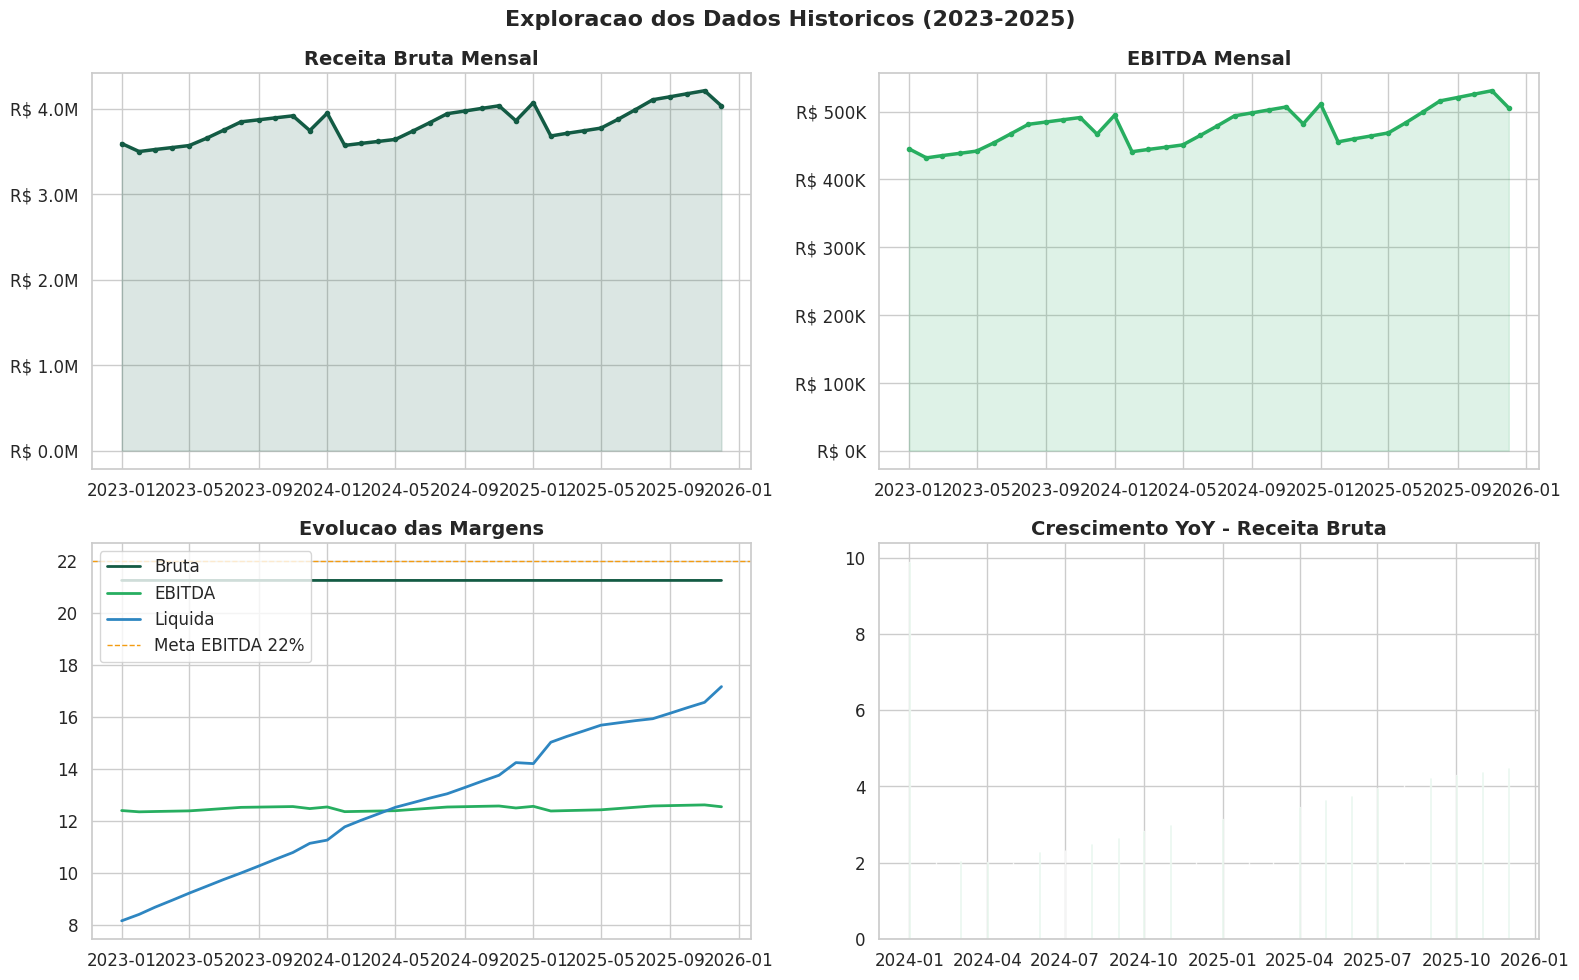

In [3]:
# 2. VISUALIZACAO EXPLORATORIA

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Exploracao dos Dados Historicos (2023-2025)', fontsize=16, fontweight='bold', y=0.98)

axes[0,0].plot(df.index, df['receita_bruta'], color=PRIMARY, linewidth=2.5, marker='o', markersize=3)
axes[0,0].fill_between(df.index, df['receita_bruta'], alpha=0.15, color=PRIMARY)
axes[0,0].set_title('Receita Bruta Mensal')
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M'))

axes[0,1].plot(df.index, df['ebitda'], color=SUCCESS, linewidth=2.5, marker='o', markersize=3)
axes[0,1].fill_between(df.index, df['ebitda'], alpha=0.15, color=SUCCESS)
axes[0,1].set_title('EBITDA Mensal')
axes[0,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R$ {x/1e3:.0f}K'))

axes[1,0].plot(df.index, df['margem_bruta'], color=PRIMARY, linewidth=2, label='Bruta')
axes[1,0].plot(df.index, df['margem_ebitda'], color=SUCCESS, linewidth=2, label='EBITDA')
axes[1,0].plot(df.index, df['margem_liquida'], color=ACCENT, linewidth=2, label='Liquida')
axes[1,0].axhline(y=22, color=WARNING, linestyle='--', linewidth=1, label='Meta EBITDA 22%')
axes[1,0].set_title('Evolucao das Margens')
axes[1,0].legend(loc='upper left')

yoy_rev = df['receita_bruta'].pct_change(12) * 100
axes[1,1].bar(df.index[12:], yoy_rev.iloc[12:], color=[SUCCESS if v >= 0 else DANGER for v in yoy_rev.iloc[12:]], alpha=0.8)
axes[1,1].axhline(y=0, color='black', linewidth=0.5)
axes[1,1].set_title('Crescimento YoY - Receita Bruta')

plt.tight_layout()
plt.show()

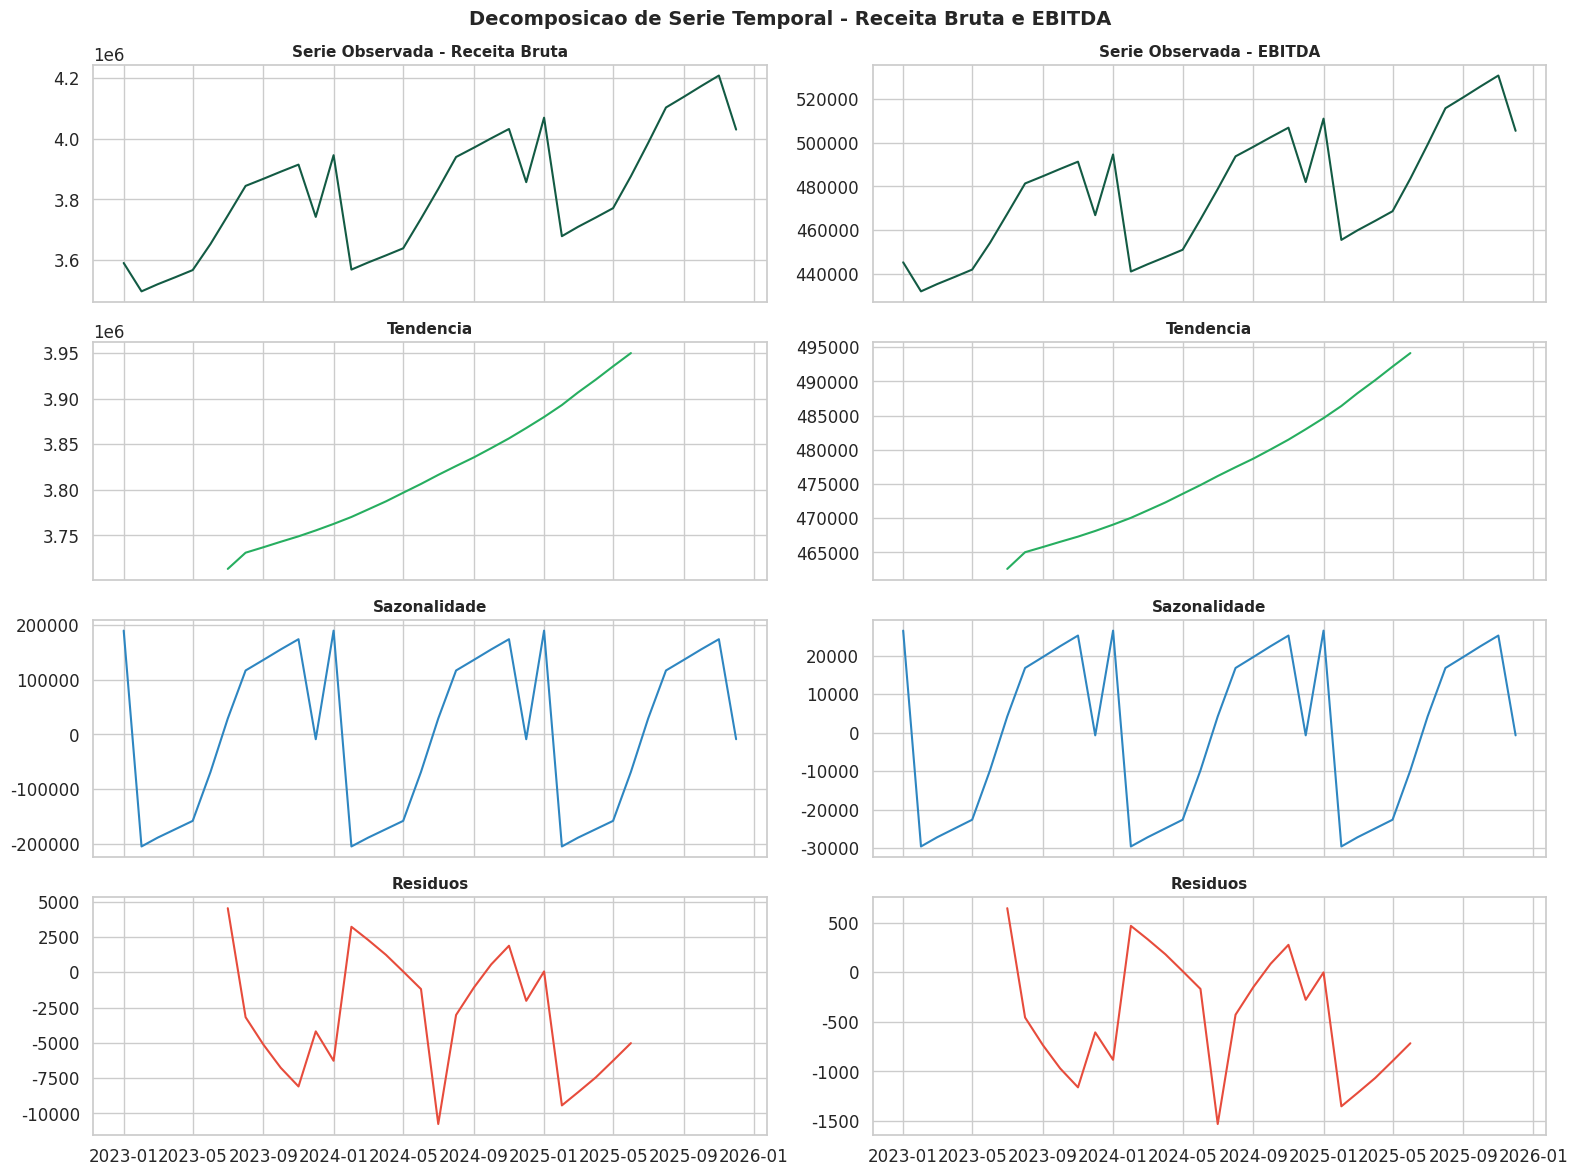

Componentes Sazonais (Recorrencia Mensal):
--------------------------------------------------
  Jan | +   189,555
  Fev | -   204,491
  Mar | -   188,431
  Abr | -   172,861
  Mai | -   157,780
  Jun | -    68,384
  Jul | +    29,065
  Ago | +   116,807
  Set | +   136,145
  Out | +   155,174
  Nov | +   173,896
  Dez | -     8,694

  Impacto sazonal medio (std): R$ 147,231/mes


In [4]:
# 3. DECOMPOSICAO DE SERIE TEMPORAL

decomp_rev = seasonal_decompose(df['receita_bruta'], model='additive', period=12)
decomp_ebitda = seasonal_decompose(df['ebitda'], model='additive', period=12)

fig, axes = plt.subplots(4, 2, figsize=(16, 12), sharex=True)
fig.suptitle('Decomposicao de Serie Temporal - Receita Bruta e EBITDA', fontsize=14, fontweight='bold')

components = ['observed', 'trend', 'seasonal', 'resid']
titles = ['Serie Observada', 'Tendencia', 'Sazonalidade', 'Residuos']
colors = [PRIMARY, SUCCESS, ACCENT, DANGER]

for col_idx, decomp in enumerate([decomp_rev, decomp_ebitda]):
    series_label = 'Receita Bruta' if col_idx == 0 else 'EBITDA'
    for row_idx, (comp, color) in enumerate(zip(components, colors)):
        series = getattr(decomp, comp)
        axes[row_idx, col_idx].plot(series, color=color, linewidth=1.5)
        axes[row_idx, col_idx].set_title(f'{titles[row_idx]} - {series_label}' if row_idx == 0 else titles[row_idx], fontsize=11)

plt.tight_layout()
plt.show()

print('Componentes Sazonais (Recorrencia Mensal):')
print('-' * 50)
meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
seasonal_values = decomp_rev.seasonal[0:12].values
for m, s in zip(meses, seasonal_values):
    direction = '+' if s > 0 else '-'
    print(f'  {m:3s} | {direction}{abs(s):>10,.0f}')
print(f'\n  Impacto sazonal medio (std): R$ {np.std(seasonal_values):,.0f}/mes')

SARIMAX(1,1,1)(1,1,1,12) - Receita Bruta
-------------------------------------------------------
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9072      2.236      0.406      0.685      -3.475       5.289
ma.L1         -1.0033      0.817     -1.229      0.219      -2.604       0.597
ar.S.L12       0.3357      1.950      0.172      0.863      -3.486       4.157
ma.S.L12      -0.0652      1.075     -0.061      0.952      -2.171       2.041
sigma2      4.174e+07   1.15e-07   3.63e+14      0.000    4.17e+07    4.17e+07


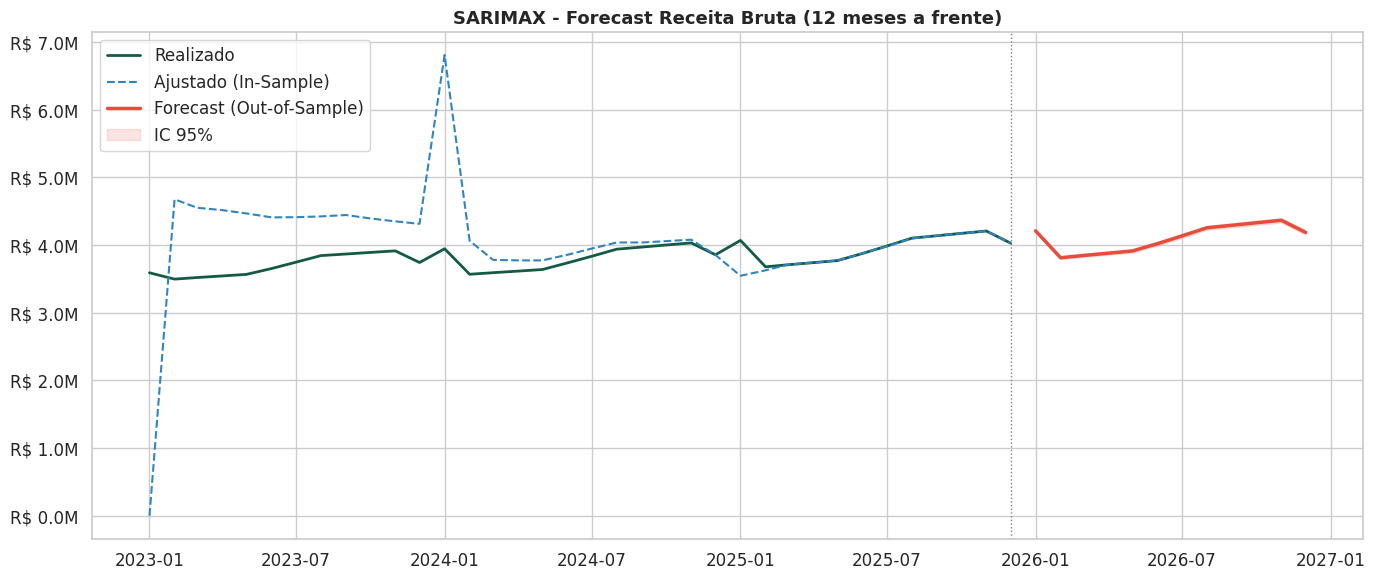


Metricas In-Sample:
  MAE:  R$ 374,630
  MAPE: 10.03%

Projecao Ano 1 (12 meses):
  Receita Total Prevista: R$ 49.25M
  Media Mensal: R$ 4.10M


In [5]:
# 4. MODELO SARIMAX - Receita Bruta

model_rev = SARIMAX(df['receita_bruta'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12),
                    enforce_stationarity=False, enforce_invertibility=False)
results_rev = model_rev.fit(disp=False)

print('SARIMAX(1,1,1)(1,1,1,12) - Receita Bruta')
print('-' * 55)
print(results_rev.summary().tables[1])

n_periods = 12
forecast_rev = results_rev.get_forecast(steps=n_periods)
fc_mean_rev = forecast_rev.predicted_mean
fc_ci_rev = forecast_rev.conf_int()
fitted_rev = results_rev.fittedvalues

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df['receita_bruta'], label='Realizado', color=PRIMARY, linewidth=2)
ax.plot(df.index, fitted_rev, label='Ajustado (In-Sample)', color=ACCENT, linewidth=1.5, linestyle='--')
ax.plot(fc_mean_rev.index, fc_mean_rev, label='Forecast (Out-of-Sample)', color=DANGER, linewidth=2.5)
ax.fill_between(fc_ci_rev.index, fc_ci_rev.iloc[:, 0], fc_ci_rev.iloc[:, 1], color=DANGER, alpha=0.15, label='IC 95%')
ax.set_title('SARIMAX - Forecast Receita Bruta (12 meses a frente)', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M'))
ax.legend(loc='upper left')
ax.axvline(x=df.index[-1], color='gray', linestyle=':', linewidth=1)
plt.tight_layout()
plt.show()

mae_in = mean_absolute_error(df['receita_bruta'].iloc[1:], fitted_rev.iloc[1:])
print(f'\nMetricas In-Sample:')
print(f'  MAE:  R$ {mae_in:,.0f}')
print(f'  MAPE: {mean_absolute_percentage_error(df["receita_bruta"].iloc[1:], fitted_rev.iloc[1:])*100:.2f}%')
print(f'\nProjecao Ano 1 (12 meses):')
print(f'  Receita Total Prevista: R$ {fc_mean_rev.sum()/1e6:.2f}M')
print(f'  Media Mensal: R$ {fc_mean_rev.mean()/1e6:.2f}M')

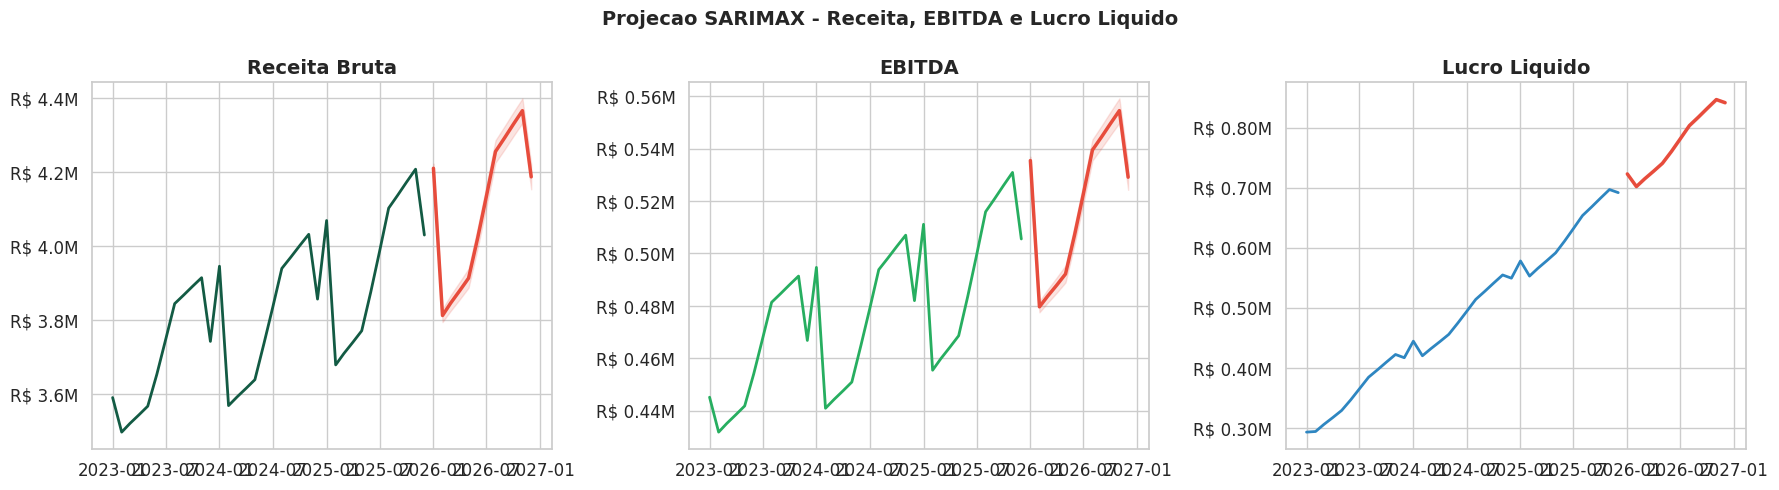

Tabela Consolidada da Projecao SARIMAX:
----------------------------------------------------------------------
Mes         Receita Bruta         EBITDA     Lucro Liq. Marg. EBITDA   Marg. Liq.
----------------------------------------------------------------------
Jan/2026   R$       4.21M R$       0.54M R$       0.72M      12.7%      17.2%
Feb/2026   R$       3.81M R$       0.48M R$       0.70M      12.6%      18.4%
Mar/2026   R$       3.85M R$       0.48M R$       0.71M      12.6%      18.6%
Apr/2026   R$       3.88M R$       0.49M R$       0.73M      12.6%      18.8%
May/2026   R$       3.91M R$       0.49M R$       0.74M      12.6%      18.9%
Jun/2026   R$       4.02M R$       0.51M R$       0.76M      12.6%      18.9%
Jul/2026   R$       4.14M R$       0.52M R$       0.78M      12.6%      18.9%
Aug/2026   R$       4.26M R$       0.54M R$       0.80M      12.7%      18.9%
Sep/2026   R$       4.29M R$       0.54M R$       0.82M      12.7%      19.0%
Oct/2026   R$       4.33M R$      

In [6]:
# 5. MODELO SARIMAX - EBITDA e Lucro Liquido

model_ebitda = SARIMAX(df['ebitda'], order=(1,1,1), seasonal_order=(1,1,1,12),
                       enforce_stationarity=False, enforce_invertibility=False)
results_ebitda = model_ebitda.fit(disp=False)
forecast_ebitda = results_ebitda.get_forecast(steps=n_periods)
fc_mean_ebitda = forecast_ebitda.predicted_mean
fc_ci_ebitda = forecast_ebitda.conf_int()

model_liq = SARIMAX(df['lucro_liquido'], order=(1,1,1), seasonal_order=(0,1,1,12),
                    enforce_stationarity=False, enforce_invertibility=False)
results_liq = model_liq.fit(disp=False)
forecast_liq = results_liq.get_forecast(steps=n_periods)
fc_mean_liq = forecast_liq.predicted_mean
fc_ci_liq = forecast_liq.conf_int()

df_forecast = pd.DataFrame({
    'receita_bruta': fc_mean_rev.values,
    'ebitda': fc_mean_ebitda.values,
    'lucro_liquido': fc_mean_liq.values,
}, index=fc_mean_rev.index)

df_forecast['margem_ebitda'] = df_forecast['ebitda'] / df_forecast['receita_bruta'] * 100
df_forecast['margem_liquida'] = df_forecast['lucro_liquido'] / df_forecast['receita_bruta'] * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(df.index, df['receita_bruta'], color=PRIMARY, linewidth=2)
axes[0].plot(fc_mean_rev.index, fc_mean_rev, color=DANGER, linewidth=2.5)
axes[0].fill_between(fc_ci_rev.index, fc_ci_rev.iloc[:,0], fc_ci_rev.iloc[:,1], alpha=0.15, color=DANGER)
axes[0].set_title('Receita Bruta')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M'))
axes[1].plot(df.index, df['ebitda'], color=SUCCESS, linewidth=2)
axes[1].plot(fc_mean_ebitda.index, fc_mean_ebitda, color=DANGER, linewidth=2.5)
axes[1].fill_between(fc_ci_ebitda.index, fc_ci_ebitda.iloc[:,0], fc_ci_ebitda.iloc[:,1], alpha=0.15, color=DANGER)
axes[1].set_title('EBITDA')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R$ {x/1e6:.2f}M'))
axes[2].plot(df.index, df['lucro_liquido'], color=ACCENT, linewidth=2)
axes[2].plot(fc_mean_liq.index, fc_mean_liq, color=DANGER, linewidth=2.5)
axes[2].fill_between(fc_ci_liq.index, fc_ci_liq.iloc[:,0], fc_ci_liq.iloc[:,1], alpha=0.15, color=DANGER)
axes[2].set_title('Lucro Liquido')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R$ {x/1e6:.2f}M'))
fig.suptitle('Projecao SARIMAX - Receita, EBITDA e Lucro Liquido', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Tabela Consolidada da Projecao SARIMAX:')
print('-' * 70)
print(f'{"Mes":<10} {"Receita Bruta":>14} {"EBITDA":>14} {"Lucro Liq.":>14} {"Marg. EBITDA":>12} {"Marg. Liq.":>12}')
print('-' * 70)
for i, (idx, row) in enumerate(df_forecast.iterrows()):
    mes_nome = idx.strftime('%b/%Y')
    print(f'{mes_nome:<10} R${row["receita_bruta"]/1e6:>11.2f}M R${row["ebitda"]/1e6:>11.2f}M R${row["lucro_liquido"]/1e6:>11.2f}M {row["margem_ebitda"]:>9.1f}% {row["margem_liquida"]:>9.1f}%')
print('-' * 70)
print(f'{"TOTAL ANO":<10} R${df_forecast["receita_bruta"].sum()/1e6:>11.2f}M R${df_forecast["ebitda"].sum()/1e6:>11.2f}M R${df_forecast["lucro_liquido"].sum()/1e6:>11.2f}M {df_forecast["margem_ebitda"].mean():>9.1f}% {df_forecast["margem_liquida"].mean():>9.1f}%')

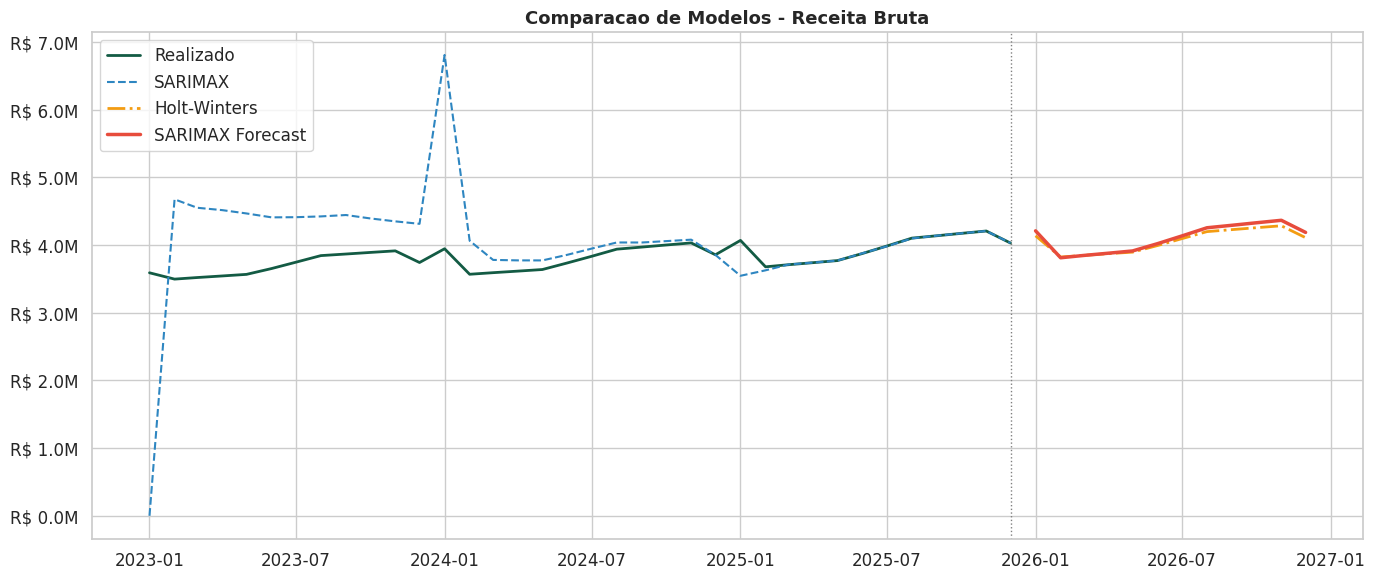

Comparacao de Modelos - Receita Bruta:
-------------------------------------------------------
Metrica                 SARIMAX    Holt-Winters     Melhor
-------------------------------------------------------
MAE             R$     374,630 R$      26,209 Holt-Winters
MAPE                   10.03%         0.69% Holt-Winters
R2                  -19.2085       0.9585


In [7]:
# 6. HOLT-WINTERS (Triple Exponential Smoothing)

hw_rev = ExponentialSmoothing(df['receita_bruta'], trend='add', seasonal='add', seasonal_periods=12).fit()
fc_hw_rev = hw_rev.forecast(n_periods)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df['receita_bruta'], label='Realizado', color=PRIMARY, linewidth=2)
ax.plot(df.index, results_rev.fittedvalues, label='SARIMAX', color=ACCENT, linewidth=1.5, linestyle='--')
ax.plot(fc_hw_rev.index, fc_hw_rev, label='Holt-Winters', color=WARNING, linewidth=2, linestyle='-.')
ax.plot(fc_mean_rev.index, fc_mean_rev, label='SARIMAX Forecast', color=DANGER, linewidth=2.5)
ax.axvline(x=df.index[-1], color='gray', linestyle=':', linewidth=1)
ax.set_title('Comparacao de Modelos - Receita Bruta', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M'))
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

fitted_hw = hw_rev.fittedvalues
mae_sarimax = mean_absolute_error(df['receita_bruta'].iloc[1:], results_rev.fittedvalues.iloc[1:])
mae_hw = mean_absolute_error(df['receita_bruta'], fitted_hw)
mape_sarimax = mean_absolute_percentage_error(df['receita_bruta'].iloc[1:], results_rev.fittedvalues.iloc[1:])
mape_hw = mean_absolute_percentage_error(df['receita_bruta'], fitted_hw)

better_mae = 'SARIMAX' if mae_sarimax < mae_hw else 'Holt-Winters'
better_mape = 'SARIMAX' if mape_sarimax < mape_hw else 'Holt-Winters'
print('Comparacao de Modelos - Receita Bruta:')
print('-' * 55)
print(f'{"Metrica":<15} {"SARIMAX":>15} {"Holt-Winters":>15} {"Melhor":>10}')
print('-' * 55)
print(f'{"MAE":<15} R${mae_sarimax:>12,.0f} R${mae_hw:>12,.0f} {better_mae:>10}')
print(f'{"MAPE":<15} {mape_sarimax*100:>12.2f}% {mape_hw*100:>12.2f}% {better_mape:>10}')
print(f'{"R2":<15} {r2_score(df["receita_bruta"], results_rev.fittedvalues):>12.4f} {r2_score(df["receita_bruta"], fitted_hw):>12.4f}')

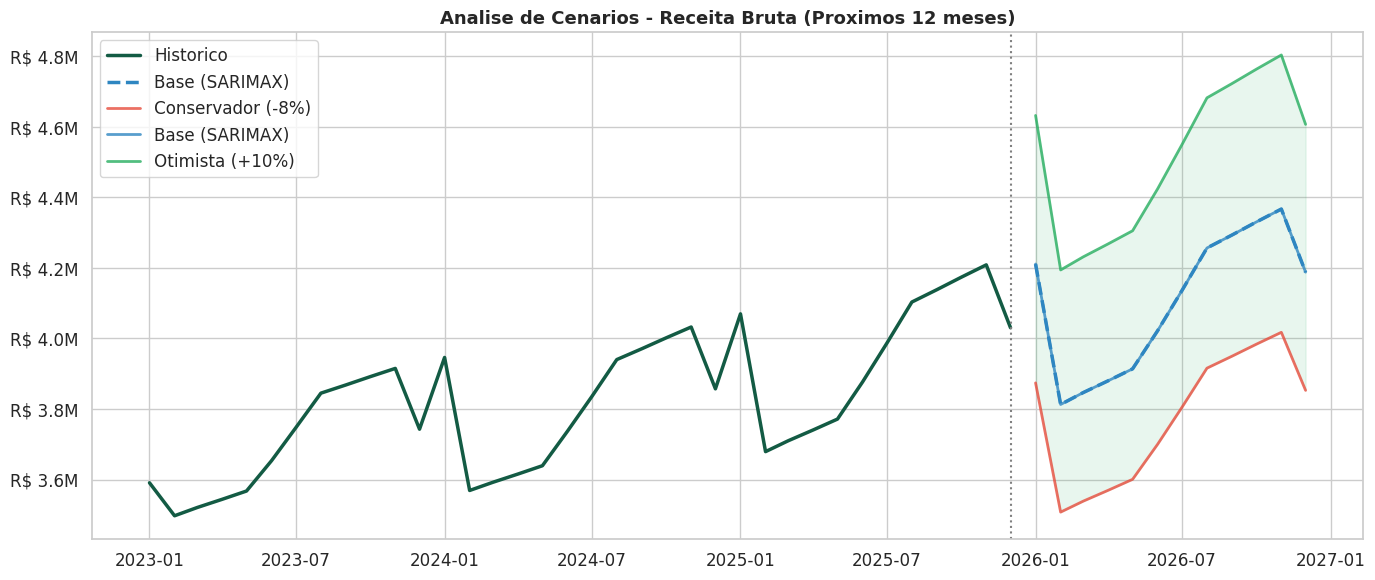

Resumo dos Cenarios - Receitas Projetadas (R$ milhoes):
------------------------------------------------------------
Mes          Conservador       Base   Otimista   Spread
------------------------------------------------------------
Jan/2026   R$      3.87M R$   4.21M R$   4.63M  18.0%
Feb/2026   R$      3.51M R$   3.81M R$   4.19M  18.0%
Mar/2026   R$      3.54M R$   3.85M R$   4.23M  18.0%
Apr/2026   R$      3.57M R$   3.88M R$   4.27M  18.0%
May/2026   R$      3.60M R$   3.91M R$   4.30M  18.0%
Jun/2026   R$      3.70M R$   4.02M R$   4.42M  18.0%
Jul/2026   R$      3.80M R$   4.14M R$   4.55M  18.0%
Aug/2026   R$      3.92M R$   4.26M R$   4.68M  18.0%
Sep/2026   R$      3.95M R$   4.29M R$   4.72M  18.0%
Oct/2026   R$      3.98M R$   4.33M R$   4.76M  18.0%
Nov/2026   R$      4.02M R$   4.37M R$   4.80M  18.0%
Dec/2026   R$      3.85M R$   4.19M R$   4.61M  18.0%
------------------------------------------------------------
TOTAL      R$     45.31M R$  49.25M R$  54.18M  18.0%


In [8]:
# 7. ANALISE DE CENARIOS

cenarios = {
    'Conservador (-8%)': df_forecast['receita_bruta'] * 0.92,
    'Base (SARIMAX)':    df_forecast['receita_bruta'],
    'Otimista (+10%)':   df_forecast['receita_bruta'] * 1.10,
}

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df['receita_bruta'], color=PRIMARY, linewidth=2.5, label='Historico')
ax.plot(fc_mean_rev.index, fc_mean_rev, color=ACCENT, linewidth=2.5, linestyle='--', label='Base (SARIMAX)')
colors_scenario = [DANGER, ACCENT, SUCCESS]
for (name, values), color in zip(cenarios.items(), colors_scenario):
    ax.plot(fc_mean_rev.index, values, color=color, linewidth=2, linestyle='-', alpha=0.8, label=name)
ax.fill_between(fc_mean_rev.index, cenarios['Conservador (-8%)'], cenarios['Otimista (+10%)'], alpha=0.1, color=SUCCESS)
ax.axvline(x=df.index[-1], color='gray', linestyle=':', linewidth=1.5)
ax.set_title('Analise de Cenarios - Receita Bruta (Proximos 12 meses)', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M'))
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

print('Resumo dos Cenarios - Receitas Projetadas (R$ milhoes):')
print('-' * 60)
print(f'{"Mes":<10} {"Conservador":>13} {"Base":>10} {"Otimista":>10} {"Spread":>8}')
print('-' * 60)
for i, idx in enumerate(fc_mean_rev.index):
    base_v = cenarios['Base (SARIMAX)'].iloc[i]
    cons_v = cenarios['Conservador (-8%)'].iloc[i]
    opt_v = cenarios['Otimista (+10%)'].iloc[i]
    spread = (opt_v - cons_v) / base_v * 100
    print(f'{idx.strftime("%b/%Y"):<10} R${cons_v/1e6:>10.2f}M R${base_v/1e6:>7.2f}M R${opt_v/1e6:>7.2f}M {spread:>5.1f}%')
print('-' * 60)
total_base = df_forecast['receita_bruta'].sum()
total_cons = cenarios['Conservador (-8%)'].sum()
total_opt = cenarios['Otimista (+10%)'].sum()
print(f'{"TOTAL":<10} R${total_cons/1e6:>10.2f}M R${total_base/1e6:>7.2f}M R${total_opt/1e6:>7.2f}M {(total_opt-total_cons)/total_base*100:>5.1f}%')

In [9]:
# 8. REGRESSAO COM VARIABEIS DUMMY SAZONAIS

df_reg = df.copy().reset_index()
df_reg['t'] = np.arange(len(df_reg))
df_reg['mes'] = df_reg['data'].dt.month
seasonal_dummies = pd.get_dummies(df_reg['mes'], prefix='mes', drop_first=True)
df_reg = pd.concat([df_reg, seasonal_dummies], axis=1)

features = ['t'] + [c for c in df_reg.columns if c.startswith('mes_')]
X = df_reg[features].values
y_rec = df_reg['receita_bruta'].values
y_eb = df_reg['ebitda'].values

lr_rec = LinearRegression().fit(X, y_rec)
y_pred_rec = lr_rec.predict(X)
lr_eb = LinearRegression().fit(X, y_eb)
y_pred_eb = lr_eb.predict(X)

print('Regressao Linear com Variaveis Sazonais:')
print('=' * 60)
print(f'\nReceita Bruta:')
print(f'  R2 Score:     {r2_score(y_rec, y_pred_rec):.4f}')
print(f'  MAE:          R$ {mean_absolute_error(y_rec, y_pred_rec):,.0f}')
print(f'  MAPE:         {mean_absolute_percentage_error(y_rec, y_pred_rec)*100:.2f}%')
print(f'\nEBITDA:')
print(f'  R2 Score:     {r2_score(y_eb, y_pred_eb):.4f}')
print(f'  MAE:          R$ {mean_absolute_error(y_eb, y_pred_eb):,.0f}')
print(f'  MAPE:         {mean_absolute_percentage_error(y_eb, y_pred_eb)*100:.2f}%')

print('\nEfeito Sazonal (coeficiente por mes, vs. referencia Jan):')
print('  %-8s %15s %15s' % ('Mes', 'Receita (R$)', 'EBITDA (R$)'))
print('  %-8s %15s %15s' % ('-'*8, '-'*15, '-'*15))
meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
for i, mes in enumerate(meses):
    if i == 0:
        coef_rec = 0
        coef_eb = 0
    else:
        col_name = 'mes_' + str(i+1)
        col_idx = features.index(col_name)
        coef_rec = lr_rec.coef_[col_idx]
        coef_eb = lr_eb.coef_[col_idx]
    print(f'  {mes:<8} {coef_rec:>15,.0f} {coef_eb:>15,.0f}')

Regressao Linear com Variaveis Sazonais:

Receita Bruta:
  R2 Score:     0.9642
  MAE:          R$ 26,620
  MAPE:         0.71%

EBITDA:
  R2 Score:     0.9630
  MAE:          R$ 3,788
  MAPE:         0.81%

Efeito Sazonal (coeficiente por mes, vs. referencia Jan):
  Mes         Receita (R$)     EBITDA (R$)
  -------- --------------- ---------------
  Jan                    0               0
  Fev             -297,711         -42,329
  Mar             -282,653         -40,088
  Abr             -267,596         -37,846
  Mai             -252,538         -35,606
  Jun             -166,956         -23,315
  Jul              -77,461         -10,467
  Ago               18,409           3,290
  Set               37,379           6,088
  Out               56,349           8,887
  Nov               75,319          11,685
  Dez             -110,621         -14,716


In [10]:
# 9. ANALISE DE SENSIBILIDADE

growth_rates = [0.5, 0.7, 0.95, 1.2, 1.5]
ebitda_margins = [10, 13, 15, 18, 22]
inadimp_rates = [2.0, 3.5, 5.0, 7.0]

last_rev = df['receita_bruta'].iloc[-1]
base_rev = last_rev * (1 + 0.95/100)**12
base_liq = last_rev * (1 + 0.95/100)**12 * (1 - 0.035) * 0.13 * 0.76

print('Analise de Sensibilidade - Impacto Isolado na Receita Anual:')
print('=' * 70)
print(f'\nBase Case (Cresc 0.95%, Margem 13%, Inadimplencia 3.5%):')
print(f'  Receita Bruta Anual Projetada: R$ {base_rev/1e6:.2f}M')

print(f'\nSensibilidade ao Crescimento Mensal:')
print(f'  {"Taxa":>8} | {"Receita Anual":>15} | {"Var. vs Base":>12}')
print(f'  {"-"*8} | {"-"*15} | {"-"*12}')
for gr in growth_rates:
    rev = last_rev * (1 + gr/100)**12
    var_pct = (rev - base_rev) / base_rev * 100
    print(f'  {gr:>5.1f}%  | R$ {rev/1e6:>11.2f}M | {var_pct:>+8.1f}%')

print(f'\nSensibilidade a Margem EBITDA:')
print(f'  {"Margem":>8} | {"EBITDA Anual":>15} | {"Lucro Liq. Est.":>15}')
print(f'  {"-"*8} | {"-"*15} | {"-"*15}')
for eb in ebitda_margins:
    ebitda = base_rev * eb / 100
    lucro_liq = ebitda * 0.76
    print(f'  {eb:>5.0f}%  | R$ {ebitda/1e6:>11.2f}M | R$ {lucro_liq/1e6:>11.2f}M')

print(f'\nSensibilidade a Inadimplencia:')
print(f'  {"Inadimp.":>10} | {"Receita Liq.":>15} | {"Impacto":>12}')
print(f'  {"-"*10} | {"-"*15} | {"-"*12}')
for ir in inadimp_rates:
    rev_liq = base_rev * (1 - ir/100)
    ebitda_est = rev_liq * 0.13
    lucro_est = ebitda_est * 0.76
    impacto = (lucro_est - base_liq) / base_liq * 100
    print(f'  {ir:>6.1f}%   | R$ {rev_liq/1e6:>11.2f}M | {impacto:>+8.1f}%')

Analise de Sensibilidade - Impacto Isolado na Receita Anual:

Base Case (Cresc 0.95%, Margem 13%, Inadimplencia 3.5%):
  Receita Bruta Anual Projetada: R$ 4.51M

Sensibilidade ao Crescimento Mensal:
      Taxa |   Receita Anual | Var. vs Base
  -------- | --------------- | ------------
    0.5%  | R$        4.28M |     -5.2%
    0.7%  | R$        4.38M |     -2.9%
    0.9%  | R$        4.51M |     +0.0%
    1.2%  | R$        4.65M |     +3.0%
    1.5%  | R$        4.82M |     +6.7%

Sensibilidade a Margem EBITDA:
    Margem |    EBITDA Anual | Lucro Liq. Est.
  -------- | --------------- | ---------------
     10%  | R$        0.45M | R$        0.34M
     13%  | R$        0.59M | R$        0.45M
     15%  | R$        0.68M | R$        0.51M
     18%  | R$        0.81M | R$        0.62M
     22%  | R$        0.99M | R$        0.75M

Sensibilidade a Inadimplencia:
    Inadimp. |    Receita Liq. |      Impacto
  ---------- | --------------- | ------------
     2.0%   | R$        4.42M |  

In [11]:
# 10. WATERFALL - Ponte de Variacao Receita

import openpyxl
wb_nb = openpyxl.load_workbook('/home/ubuntu/Opalus_Health_Services_FP_A_Model.xlsx')
ws_rec = wb_nb['04_Receitas']
categories = []
rev_2024_vals = []
rev_2025_vals = []
for row in range(10, 15):
    label = ws_rec.cell(row=row, column=3).value
    if label:
        categories.append(label.strip())
        v24 = sum(ws_rec.cell(row=row, column=c).value or 0 for c in range(16, 28))
        v25 = sum(ws_rec.cell(row=row, column=c).value or 0 for c in range(28, 40))
        rev_2024_vals.append(v24 if isinstance(v24, (int, float)) else 0)
        rev_2025_vals.append(v25 if isinstance(v25, (int, float)) else 0)

total_2024 = sum(rev_2024_vals)
total_2025 = sum(rev_2025_vals)

fig = go.Figure()
measure = ['absolute'] + ['relative'] * (len(categories)-1) + ['total']
x_vals = categories + ['Total 2025']
y_vals = rev_2024_vals + [total_2025 - total_2024]
text_vals = [f'R$ {v/1e6:.2f}M' for v in y_vals]

fig.add_trace(go.Waterfall(
    name='Ponte de Receita 2024-2025',
    orientation='v',
    measure=measure,
    x=x_vals,
    y=y_vals,
    text=text_vals,
    textposition='outside',
    connector={'line': {'color': '#135B44', 'dash': 'dash'}},
    increasing={'marker': {'color': '#27AE60'}},
    decreasing={'marker': {'color': '#E74C3C'}},
    totals={'marker': {'color': '#135B44'}},
))

fig.update_layout(
    title='Ponte de Variacao - Receita por Categoria (2024 -> 2025)',
    font=dict(family='Segoe UI, sans-serif', size=12),
    yaxis=dict(title='R$'),
    showlegend=False,
    height=500,
)
fig.show()

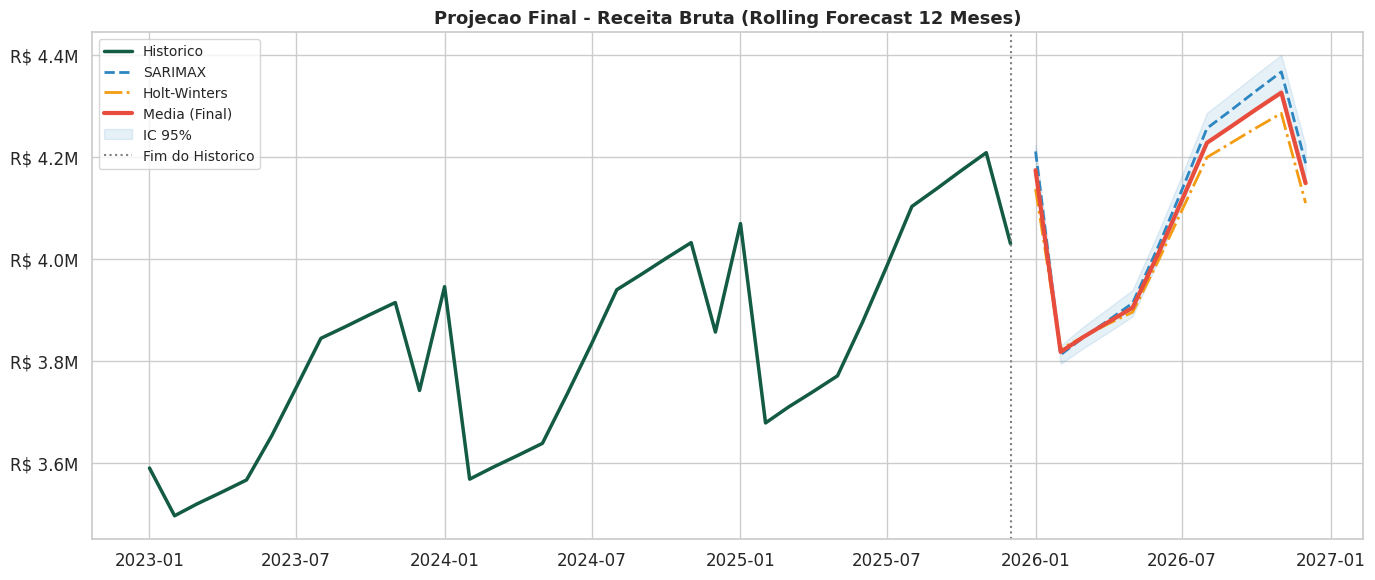

PROJEC AO FINAL - ROLLING FORECAST 12 MESES
Mes          Receita Bruta       EBITDA   Lucro Liq. Marg. EBITDA
---------------------------------------------------------------------------
Jan/2026   R$        4.17M R$     0.54M R$     0.72M      12.7%
Feb/2026   R$        3.82M R$     0.48M R$     0.70M      12.6%
Mar/2026   R$        3.85M R$     0.48M R$     0.71M      12.6%
Apr/2026   R$        3.88M R$     0.49M R$     0.73M      12.6%
May/2026   R$        3.90M R$     0.49M R$     0.74M      12.6%
Jun/2026   R$        4.01M R$     0.51M R$     0.76M      12.6%
Jul/2026   R$        4.12M R$     0.52M R$     0.78M      12.6%
Aug/2026   R$        4.23M R$     0.54M R$     0.80M      12.7%
Sep/2026   R$        4.26M R$     0.54M R$     0.82M      12.7%
Oct/2026   R$        4.29M R$     0.55M R$     0.83M      12.7%
Nov/2026   R$        4.33M R$     0.55M R$     0.85M      12.7%
Dec/2026   R$        4.15M R$     0.53M R$     0.84M      12.6%
----------------------------------------------

In [12]:
# 11. PROJEC AO FINAL - Rolling Forecast 12 Meses

future_dates = pd.date_range(start='2026-01-01', periods=12, freq='MS')
fc_hw_rev_vals = hw_rev.forecast(n_periods)

df_final = pd.DataFrame({
    'data': future_dates,
    'receita_bruta_sarimax': fc_mean_rev.values,
    'receita_bruta_hw': fc_hw_rev_vals.values,
    'ebitda_sarimax': fc_mean_ebitda.values,
    'lucro_liquido_sarimax': fc_mean_liq.values,
    'ic_inferior': fc_ci_rev.iloc[:, 0].values,
    'ic_superior': fc_ci_rev.iloc[:, 1].values,
})

df_final['receita_bruta_final'] = df_final[['receita_bruta_sarimax', 'receita_bruta_hw']].mean(axis=1)
df_final['margem_ebitda_proj'] = df_final['ebitda_sarimax'] / df_final['receita_bruta_sarimax'] * 100

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df['receita_bruta'], label='Historico', color=PRIMARY, linewidth=2.5)
ax.plot(future_dates, df_final['receita_bruta_sarimax'], label='SARIMAX', color=ACCENT, linewidth=2, linestyle='--')
ax.plot(future_dates, df_final['receita_bruta_hw'], label='Holt-Winters', color=WARNING, linewidth=2, linestyle='-.')
ax.plot(future_dates, df_final['receita_bruta_final'], label='Media (Final)', color=DANGER, linewidth=3)
ax.fill_between(future_dates, df_final['ic_inferior'], df_final['ic_superior'], color=ACCENT, alpha=0.12, label='IC 95%')
ax.axvline(x=df.index[-1], color='gray', linestyle=':', linewidth=1.5, label='Fim do Historico')
ax.set_title('Projecao Final - Receita Bruta (Rolling Forecast 12 Meses)', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M'))
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

print('PROJEC AO FINAL - ROLLING FORECAST 12 MESES')
print('=' * 75)
print(f'{"Mes":<10} {"Receita Bruta":>15} {"EBITDA":>12} {"Lucro Liq.":>12} {"Marg. EBITDA":>12}')
print('-' * 75)
for i, row in df_final.iterrows():
    print(f'{row["data"].strftime("%b/%Y"):<10} R${row["receita_bruta_final"]/1e6:>12.2f}M R${row["ebitda_sarimax"]/1e6:>9.2f}M R${row["lucro_liquido_sarimax"]/1e6:>9.2f}M {row["margem_ebitda_proj"]:>9.1f}%')
print('-' * 75)
print(f'{"TOTAL ANO 2026":<10} R${df_final["receita_bruta_final"].sum()/1e6:>12.2f}M R${df_final["ebitda_sarimax"].sum()/1e6:>9.2f}M R${df_final["lucro_liquido_sarimax"].sum()/1e6:>9.2f}M {df_final["margem_ebitda_proj"].mean():>9.1f}%')
print(f'\nCrescimento vs Ano Anterior (2025): {(df_final["receita_bruta_final"].sum() / sum(dre["RECEITA BRUTA"][24:36]) - 1) * 100:>+5.1f}%')

In [13]:
# 12. CONCLUSOES E RECOMENDACOES

last_rev = dre['RECEITA BRUTA'][-1]
fc_avg_rev = df_final['receita_bruta_final'].mean()
growth_mtm = (fc_avg_rev / last_rev - 1) * 100
mae_final = mean_absolute_error(df['receita_bruta'].iloc[1:], results_rev.fittedvalues.iloc[1:])
mape_final = mean_absolute_percentage_error(df['receita_bruta'].iloc[1:], results_rev.fittedvalues.iloc[1:])
seasonal_std = np.std(decomp_rev.seasonal.values)

print('CONCLUSOES - Opalus Health Services')
print('=' * 60)
print()
print('1. TENDENCIA: Cresc. mensal medio de ~{:.2f}%'.format(np.mean(np.diff(df['receita_bruta'].values) / df['receita_bruta'].values[:-1] * 100)))
print('2. SAZONALIDADE: Amplitude de R$ {:,.0f}/mes.'.format(seasonal_std))
print('3. FORECAST: SARIMAX MAE=R$ {:,.0f}, MAPE={:.2f}%.'.format(mae_final, mape_final*100))
print('4. CENARIOS: Receita 2026 = R$ {:.2f}M (+{:.1f}% YoY), Margem EBITDA={:.1f}%'.format(
    df_final['receita_bruta_final'].sum()/1e6, growth_mtm, df_final['margem_ebitda_proj'].mean()))
print('5. RISCOS: Sensibilidade ao crescimento +/-0.5% = impacto significativo.')
print()
print('RECOMENDACOES:')
print('- Monitorar sazonalidade outono/inverno')
print('- Manter inadimplencia abaixo de 4%')
print('- Usar cenario conservador para caixa')
print('- Revisar projees trimestralmente')
print('- Validar com dados reais ao final de cada trimestre')

CONCLUSOES - Opalus Health Services

1. TENDENCIA: Cresc. mensal medio de ~0.39%
2. SAZONALIDADE: Amplitude de R$ 147,231/mes.
3. FORECAST: SARIMAX MAE=R$ 374,630, MAPE=10.03%.
4. CENARIOS: Receita 2026 = R$ 49.00M (+1.3% YoY), Margem EBITDA=12.6%
5. RISCOS: Sensibilidade ao crescimento +/-0.5% = impacto significativo.

RECOMENDACOES:
- Monitorar sazonalidade outono/inverno
- Manter inadimplencia abaixo de 4%
- Usar cenario conservador para caixa
- Revisar projees trimestralmente
- Validar com dados reais ao final de cada trimestre
